In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Terzo anno/Tirocinio/Python/Mixed data- Legnaro/File uniti/File/SL_filtrato.csv')
print(df)

         m_SL_0    timestamp0    m_SL_1  timestamp1
0      1.743719  1.750166e+09  0.379775  1750165544
1      2.692259  1.750166e+09  1.766440  1750165544
2     -1.441607  1.750166e+09 -0.170127  1750165545
3      1.803890  1.750166e+09 -0.423567  1750165545
4     -2.529073  1.750166e+09  0.460460  1750165546
...         ...           ...       ...         ...
18686       NaN           NaN  0.112839  1750487718
18687       NaN           NaN  1.341044  1750487718
18688       NaN           NaN  0.424061  1750487718
18689       NaN           NaN -0.044465  1750487718
18690       NaN           NaN  1.811884  1750487719

[18691 rows x 4 columns]


In [3]:
import numpy as np

# Dati di partenza
mSL0 = np.array(df.m_SL_0)
mSL1 = np.array(df.m_SL_1)
tempo0 = np.array(df.timestamp0)
tempo1 = np.array(df.timestamp1)

# Conversione timestamp in datetime
t0 = pd.to_datetime(tempo0, unit='s')
t1 = pd.to_datetime(tempo1, unit='s')

# Calcolo angoli (in gradi)
msl0_atg = np.arctan(mSL0)
msl0_arctg = np.degrees(msl0_atg)
teta_sl0 = 90 - msl0_arctg

msl1_atg = np.arctan(mSL1)
msl1_arctg = np.degrees(msl1_atg)
teta_sl1 = 90 - msl1_arctg

In [4]:
# Heatmap SL: camera verticale

/tmp/ipython-input-4183124528.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')
/tmp/ipython-input-4183124528.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data_teta = df_teta_cleaned.pivot_table(


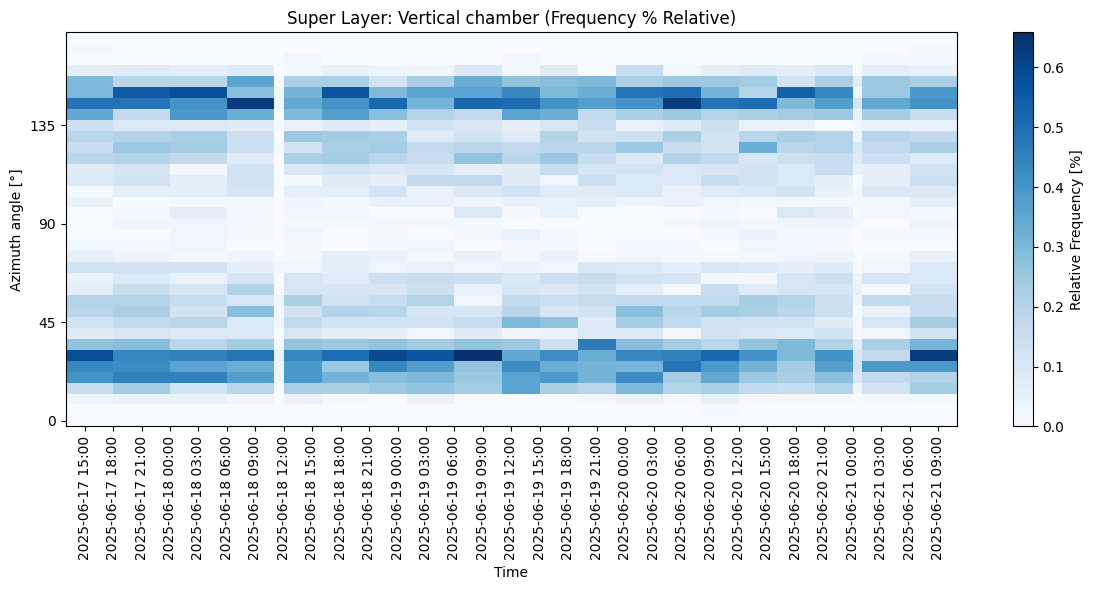

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

# Crea il DataFrame per teta_sl0
data = {'datetime': t0, 'teta_sl0': teta_sl0}
df_teta = pd.DataFrame(data)
df_teta_cleaned = df_teta.dropna(subset=['datetime', 'teta_sl0']).copy()

# Calcola i bin (ampiezza 5)
min_val = np.floor(df_teta_cleaned['teta_sl0'].min() / 10) * 10
max_val = np.ceil(df_teta_cleaned['teta_sl0'].max() / 10) * 10
bin_edges = np.arange(min_val, max_val + 5, 5)

# Assegna i valori ai bin
df_teta_cleaned['teta_sl0_bin'] = pd.cut(df_teta_cleaned['teta_sl0'], bins=bin_edges)

# Aggregazione temporale per ora
df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')

# Pivot table con conteggi assoluti
heatmap_data_teta = df_teta_cleaned.pivot_table(
    index='teta_sl0_bin',
    columns='datetime',
    values='teta_sl0',
    aggfunc='count',
    fill_value=0
)

# Calcolo della frequenza relativa percentuale globale
total_count = heatmap_data_teta.values.sum()
heatmap_percent = (heatmap_data_teta / total_count) * 100

# Meshgrid
x = mdates.date2num(heatmap_percent.columns.to_pydatetime())
if len(x) > 1:
    delta = x[-1] - x[-2]
else:
    delta = 1
x = np.append(x, x[-1] + delta)
y = np.arange(len(heatmap_percent.index) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.xlabel("Time")
plt.ylabel("Azimuth angle [°]")
plt.title("Super Layer: Vertical chamber (Frequency % Relative)")

# Asse X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
plt.xticks(rotation=90)

# Etichette Y per intervalli angolari desiderati (0°, 45°, 90°, ...)
desired_labels = [0, 45, 90, 135, 180]
yticks = []
yticklabels = []

for i, interval in enumerate(heatmap_percent.index):
    left_val = int(interval.left)
    if left_val in desired_labels:
        yticks.append(i + 0.5)
        yticklabels.append(str(left_val))

plt.yticks(ticks=yticks, labels=yticklabels, fontsize=10)

# Heatmap
pc = plt.pcolormesh(x, y, heatmap_percent.values, cmap='Blues', shading='auto')
plt.colorbar(pc, label='Relative Frequency [%]')
plt.tight_layout()
plt.show()


In [ ]:
#Heatmap: SL, camera orizzontale

/tmp/ipython-input-3325563106.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')
/tmp/ipython-input-3325563106.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data_teta = df_teta_cleaned.pivot_table(


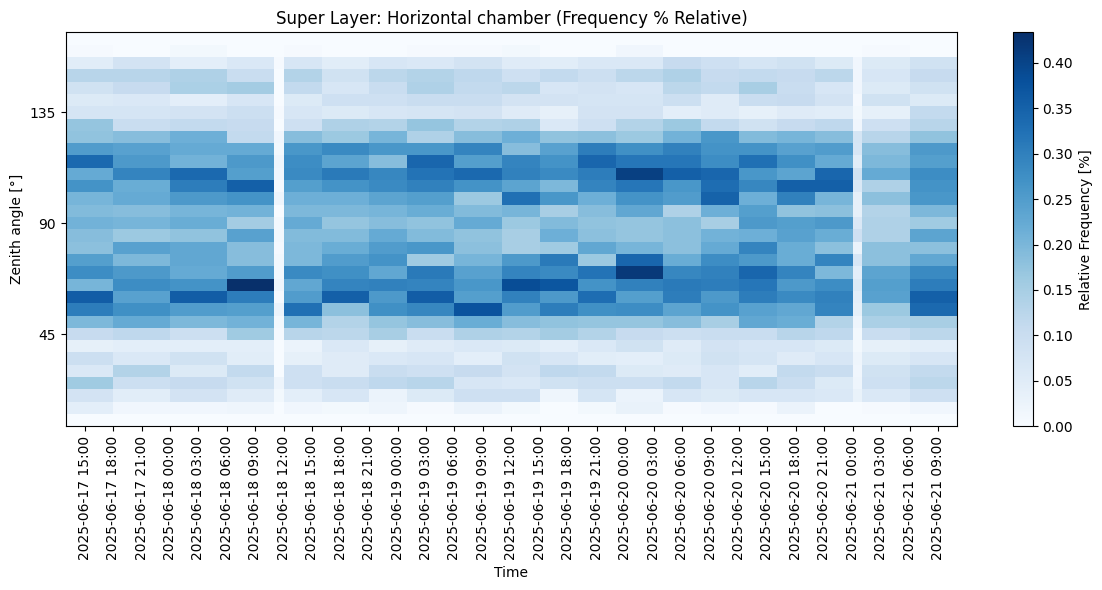

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

# Crea il DataFrame per teta_sl0
data = {'datetime': t1, 'teta_sl1': teta_sl1}
df_teta = pd.DataFrame(data)
df_teta_cleaned = df_teta.dropna(subset=['datetime', 'teta_sl1']).copy()

# Calcola i bin (ampiezza 5)
min_val = np.floor(df_teta_cleaned['teta_sl1'].min() / 10) * 10
max_val = np.ceil(df_teta_cleaned['teta_sl1'].max() / 10) * 10
bin_edges = np.arange(min_val, max_val + 5, 5)  # aggiungi +5 per includere l'ultimo bin

# Assegna i valori ai bin
df_teta_cleaned['teta_sl1_bin'] = pd.cut(df_teta_cleaned['teta_sl1'], bins=bin_edges)

df_teta_cleaned['datetime'] = df_teta_cleaned['datetime'].dt.floor('H')

# Crea la tabella pivot per la heatmap
heatmap_data_teta = df_teta_cleaned.pivot_table(
    index='teta_sl1_bin',
    columns='datetime',
    values='teta_sl1',
    aggfunc='count',
    fill_value=0
)

# Calcolo della frequenza relativa percentuale globale
total_count = heatmap_data_teta.values.sum()
heatmap_percent = (heatmap_data_teta / total_count) * 100

# Meshgrid
x = mdates.date2num(heatmap_percent.columns.to_pydatetime())
if len(x) > 1:
    delta = x[-1] - x[-2]
else:
    delta = 1
x = np.append(x, x[-1] + delta)
y = np.arange(len(heatmap_percent.index) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.xlabel("Time")
plt.ylabel("Zenith angle [°]")
plt.title("Super Layer: Horizontal chamber (Frequency % Relative)")

# Asse X
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
plt.xticks(rotation=90)

# Etichette Y per intervalli angolari desiderati (0°, 45°, 90°, ...)
desired_labels = [0, 45, 90, 135, 180]
yticks = []
yticklabels = []

for i, interval in enumerate(heatmap_percent.index):
    left_val = int(interval.left)
    if left_val in desired_labels:
        yticks.append(i + 0.5)
        yticklabels.append(str(left_val))

plt.yticks(ticks=yticks, labels=yticklabels, fontsize=10)

# Heatmap
pc = plt.pcolormesh(x, y, heatmap_percent.values, cmap='Blues', shading='auto')
plt.colorbar(pc, label='Relative Frequency [%]')
plt.tight_layout()
plt.show()
